# Challenge Part 1: Hamiltonian Dynamics

## 1.1

Imports

In [8]:
import dynamiqs as dq
import matplotlib.pyplot as plt
import jax.numpy as jnp

Given parameters

In [9]:
na, nb = 20, 5  # Hilbert space dimensions
T = 4.0  # Total simulation time

g2 = 1.0  # Two-photon coupling strength
eps_d = -4  # Drive amplitude
kappa_b = 10  # Decay rate

Computed parameters and states

In [10]:
kappa_2 = 4 * (g2**2) / kappa_b  # Two-photon loss rate
alpha = -eps_d / g2  # Amplitude of the coherent state

In [11]:
psi0 = dq.fock((na, nb), (0, 0))  # Initial state

Operators

In [12]:
a, b = dq.destroy(na, nb)
dag_a, dag_b = dq.dag(a), dq.dag(b)
H_2ph = g2 * dag_a @ dag_a @ b + jnp.conj(g2) * a @ a @ dag_b
H_d = jnp.conj(eps_d) * b + eps_d * dag_b
H = H_2ph + H_d

In [13]:
loss_op = jnp.sqrt(kappa_b) * b

Plot it

In [14]:
tsave = jnp.linspace(0, T, 100)
res = dq.mesolve(H, [loss_op], psi0, tsave)

|██████████| 100.0% ◆ elapsed 516.66ms ◆ remaining 0.00ms  


100%|██████████| 50/50 [00:03<00:00, 12.65it/s]


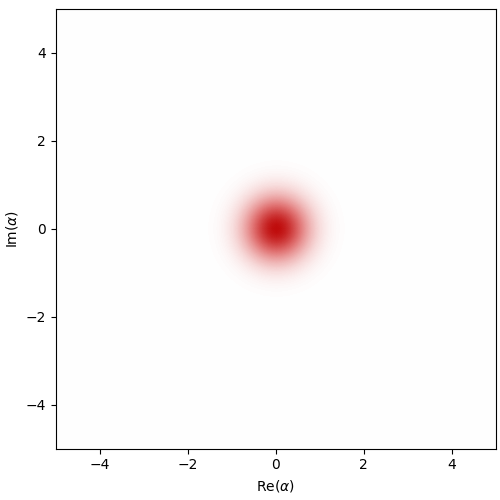

In [16]:
rho_a = dq.ptrace(res.states, 0)
# Then plot Wigner gif of rho_a
dq.plot.wigner_gif(rho_a)